<a href="https://colab.research.google.com/github/Monikha-K/Data_Science_SAT1_marketing-agency/blob/main/Data_Science_SAT_CIA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ============================================
# INFLUENCER POST ENGAGEMENT ANALYSIS
# One-Way ANOVA
# ============================================

import pandas as pd
from scipy.stats import f_oneway

# --------------------------------------------
# 1. Read the dataset
# --------------------------------------------

file_path = '/content/drive/MyDrive/Data Science SAT 1/Q20_influencer_engagement.csv'

df = pd.read_csv(file_path)

print("========== ORIGINAL DATASET ==========")
print(df.head())

print("\nDataset Shape:", df.shape)

# --------------------------------------------
# 2. Check missing values
# --------------------------------------------

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# --------------------------------------------
# 3. Treat missing engagement count
# --------------------------------------------

df['engagement_count'] = df['engagement_count'].fillna(
    df['engagement_count'].median()
)

# --------------------------------------------
# 4. Check and remove duplicate posts
# --------------------------------------------

print("\nDuplicate Posts:", df['post_id'].duplicated().sum())

df = df.drop_duplicates(subset='post_id')

print("Shape after removing duplicates:", df.shape)

# --------------------------------------------
# 5. Remove rows missing required ANOVA data
# --------------------------------------------

df_anova = df.dropna(
    subset=['post_type', 'engagement_rate_percent']
)

print("Final data shape for ANOVA:", df_anova.shape)

# --------------------------------------------
# 6. Display post type counts
# --------------------------------------------

print("\n========== POST TYPE COUNTS ==========")
print(df_anova['post_type'].value_counts())

# --------------------------------------------
# 7. Descriptive Statistics
# --------------------------------------------

print("\n========== DESCRIPTIVE STATISTICS ==========")

stats = df_anova.groupby(
    'post_type'
)['engagement_rate_percent'].describe()

print(stats)

# --------------------------------------------
# 8. Calculate mean engagement rate
# --------------------------------------------

print("\n========== MEAN ENGAGEMENT RATE ==========")

mean_engagement = df_anova.groupby(
    'post_type'
)['engagement_rate_percent'].mean()

print(mean_engagement)

# --------------------------------------------
# 9. Create groups for ANOVA
# --------------------------------------------

image = df_anova[
    df_anova['post_type'] == 'Image'
]['engagement_rate_percent']

video = df_anova[
    df_anova['post_type'] == 'Video'
]['engagement_rate_percent']

carousel = df_anova[
    df_anova['post_type'] == 'Carousel'
]['engagement_rate_percent']

# --------------------------------------------
# 10. One-Way ANOVA
# --------------------------------------------

f_stat, p_value = f_oneway(
    image,
    video,
    carousel
)

print("\n========== ONE-WAY ANOVA ==========")

print("F-statistic:", f_stat)
print("P-value:", p_value)

# --------------------------------------------
# 11. Hypothesis Testing
# --------------------------------------------

alpha = 0.05

print("\n========== HYPOTHESIS TESTING ==========")

print("H0: There is no significant difference in mean")
print("    engagement rate among Image, Video and Carousel posts.")

print("H1: There is a significant difference in mean")
print("    engagement rate among the post types.")

if p_value < alpha:
    print("\nResult: Reject H0")
    print("There is a significant difference in engagement rates.")
else:
    print("\nResult: Fail to Reject H0")
    print("There is no significant difference in engagement rates.")

# --------------------------------------------
# 12. Find highest-performing post type
# --------------------------------------------

highest_type = mean_engagement.idxmax()
highest_mean = mean_engagement.max()

print("\n========== FINAL RESULT ==========")

print("Highest Engagement Post Type:", highest_type)
print("Mean Engagement Rate:", round(highest_mean, 3), "%")

print("\nConclusion:")
print(
    f"{highest_type} posts generate the highest average "
    "engagement rate in this dataset."
)

========== ORIGINAL DATASET ==========
  post_id post_type  followers  engagement_rate_percent  engagement_count
0  IN0001     Video    13832.0                     3.92               542
1  IN0002  Carousel   177886.0                     5.55              9872
2  IN0003     Video   128149.0                     4.41              5651
3  IN0004     Video    65225.0                     4.50              2935
4  IN0005  Carousel        NaN                     1.14              1558

Dataset Shape: (123, 5)

========== MISSING VALUES ==========
post_id                    0
post_type                  1
followers                  1
engagement_rate_percent    1
engagement_count           0
dtype: int64

Duplicate Posts: 3
Shape after removing duplicates: (120, 5)
Final data shape for ANOVA: (118, 5)

========== POST TYPE COUNTS ==========
post_type
Image       45
Carousel    40
Video       33
Name: count, dtype: int64

========== DESCRIPTIVE STATISTICS ==========
           count      mean    

In [4]:
# Save complete output to Google Drive
output_file = '/content/drive/MyDrive/Data Science SAT 1/influencer_engagement_output.txt'

with open(output_file, 'w') as f:
    f.write("INFLUENCER POST ENGAGEMENT ANALYSIS\n")
    f.write("=" * 50 + "\n\n")

    f.write("DESCRIPTIVE STATISTICS\n")
    f.write(str(stats))
    f.write("\n\n")

    f.write("MEAN ENGAGEMENT RATE\n")
    f.write(str(mean_engagement))
    f.write("\n\n")

    f.write("ONE-WAY ANOVA RESULTS\n")
    f.write(f"F-statistic: {f_stat}\n")
    f.write(f"P-value: {p_value}\n\n")

    f.write("HYPOTHESIS TESTING\n")
    f.write("Significance level: 0.05\n")
    f.write(f"Result: {'Reject H0' if p_value < 0.05 else 'Fail to Reject H0'}\n\n")

    f.write("FINAL RESULT\n")
    f.write(f"Highest Engagement Post Type: {highest_type}\n")
    f.write(f"Mean Engagement Rate: {highest_mean:.3f}%\n")

print(f"\nOutput saved successfully to:\n{output_file}")


Output saved successfully to:
/content/drive/MyDrive/Data Science SAT 1/influencer_engagement_output.txt


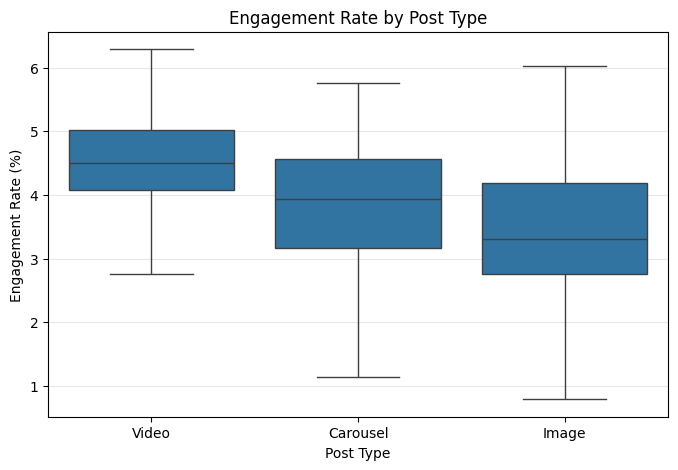

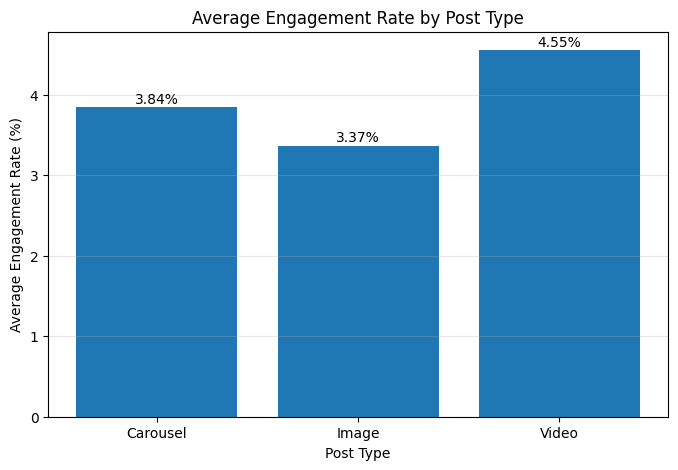

========== ANOVA DECISION ==========
F-statistic: 11.0802
P-value: 0.000040

Post format has a SIGNIFICANT effect on engagement.

========== CONTENT STRATEGY ==========
Highest performing format: Video
Average engagement rate: 4.55%

Recommendation:
The client should prioritize Video posts because they achieved the highest average engagement rate. The client can use this format more frequently while continuing to test other formats for different content goals.


In [6]:
# ============================================
# BOX PLOT AND BAR CHART
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. Box Plot
# --------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_anova,
    x='post_type',
    y='engagement_rate_percent'
)

plt.title('Engagement Rate by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Engagement Rate (%)')
plt.grid(axis='y', alpha=0.3)

plt.show()


# --------------------------------------------
# 2. Bar Chart - Mean Engagement Rate
# --------------------------------------------

mean_engagement = df_anova.groupby(
    'post_type'
)['engagement_rate_percent'].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    mean_engagement.index,
    mean_engagement.values
)

plt.title('Average Engagement Rate by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Average Engagement Rate (%)')
plt.grid(axis='y', alpha=0.3)

# Display values on bars
for i, value in enumerate(mean_engagement.values):
    plt.text(
        i,
        value + 0.05,
        f'{value:.2f}%',
        ha='center'
    )

plt.show()


# --------------------------------------------
# 3. ANOVA Decision
# --------------------------------------------

print("========== ANOVA DECISION ==========")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nPost format has a SIGNIFICANT effect on engagement.")
else:
    print("\nPost format does NOT have a significant effect on engagement.")


# --------------------------------------------
# 4. Content Strategy Recommendation
# --------------------------------------------

highest_type = mean_engagement.idxmax()
highest_mean = mean_engagement.max()

print("\n========== CONTENT STRATEGY ==========")
print(f"Highest performing format: {highest_type}")
print(f"Average engagement rate: {highest_mean:.2f}%")

print("\nRecommendation:")
print(
    f"The client should prioritize {highest_type} posts because "
    f"they achieved the highest average engagement rate. "
    "The client can use this format more frequently while "
    "continuing to test other formats for different content goals."
)